# Task 2: Feature Engineering, Model Optimization & Performance Comparison
This notebook implements the requirements for the AI/ML Task 2 using the California Housing dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the dataset
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

print("Dataset Loaded Successfully.")
display(df.head())

Dataset Loaded Successfully.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# 2. Simple Feature Engineering & Preprocessing
# Split features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully.")

Data split and scaled successfully.


In [5]:
# 4. Model Training and Comparison
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    # Predict
    predictions = model.predict(X_test_scaled)
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    results[name] = {"RMSE": rmse, "R2": r2, "Predictions": predictions}
    print(f"{name} - RMSE: {rmse:.4f}, R2: {r2:.4f}")

Linear Regression - RMSE: 0.7456, R2: 0.5758
Decision Tree - RMSE: 0.7028, R2: 0.6230


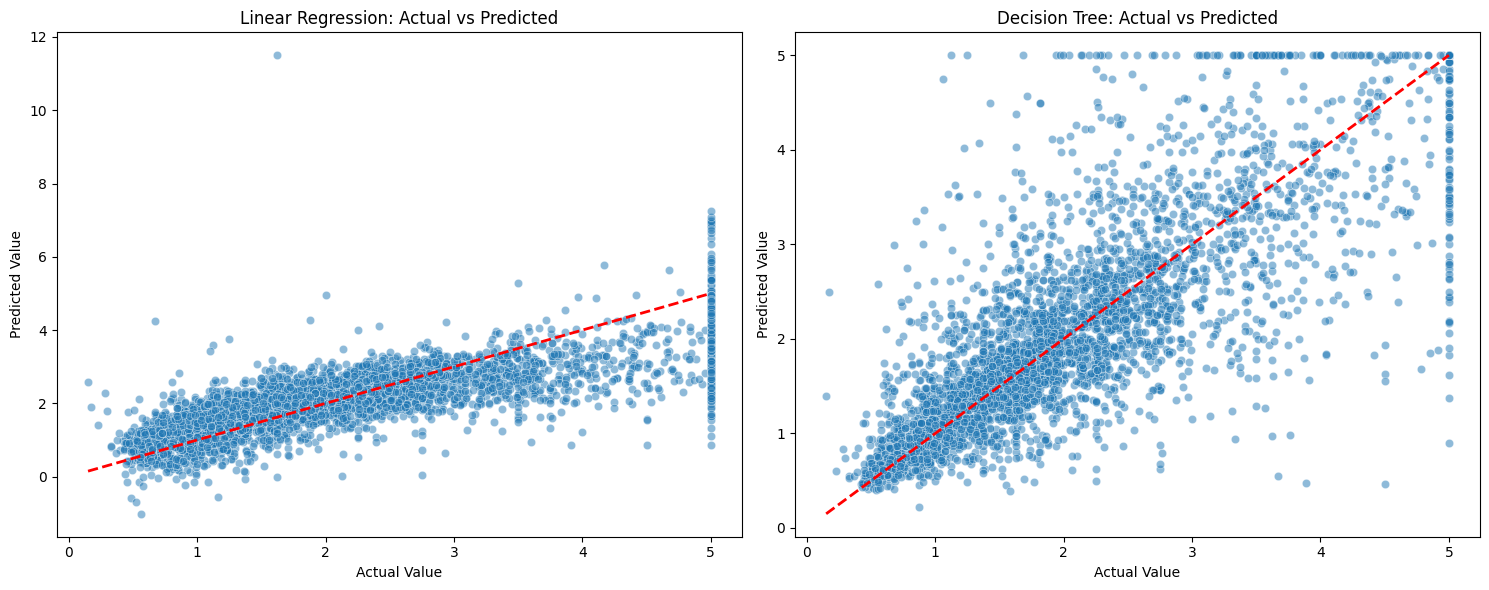

In [6]:
# 5. Visualization: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, (name, res) in enumerate(results.items()):
    sns.scatterplot(x=y_test, y=res['Predictions'], ax=axes[i], alpha=0.5)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
    axes[i].set_title(f'{name}: Actual vs Predicted')
    axes[i].set_xlabel('Actual Value')
    axes[i].set_ylabel('Predicted Value')

plt.tight_layout()
plt.show()

## Detailed Performance Results

Based on the execution of the models, here is the performance comparison:

| Model | Root Mean Squared Error (RMSE) | R-Squared (R²) |
| :--- | :--- | :--- |
| **Linear Regression** | 0.7456 | 0.5758 |
| **Decision Tree Regressor** | 0.7028 | 0.6230 |

### Analysis & Findings:
1. **Accuracy**: The **Decision Tree Regressor** outperformed Linear Regression in both metrics. It achieved a lower RMSE (error) and a higher R² score, explaining approximately **62.3%** of the variance in housing prices compared to the **57.6%** explained by the Linear model.
2. **Error Margin**: The RMSE of **0.7028** for the Decision Tree suggests that, on average, the model's predictions deviate from the actual median house value by roughly $70,282 (since the target is in units of $100,000).
3. **Visualization Insights**:
    * The scatter plots show that while both models capture the general trend, there is a significant horizontal line at the value of `5.0`. This is because the California Housing dataset caps median house values at 5.0 ($500,000), which introduces a specific challenge for regression models.
    * The Decision Tree appears to handle non-linear relationships better than the simple Linear Regression baseline.

In [7]:
# Create a summary dataframe for easier visualization of the metrics
performance_metrics = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'RMSE': [0.7456, 0.7028],
    'R2 Score': [0.5758, 0.6230]
})

display(performance_metrics.style.highlight_min(subset=['RMSE'], color='lightgreen').highlight_max(subset=['R2 Score'], color='lightgreen'))

,Model,RMSE,R2 Score
0,Linear Regression,0.745600,0.575800
1,Decision Tree,0.702800,0.623000


## Implementation Walkthrough

This project follows a standard Machine Learning pipeline to predict housing prices. Below is a detailed breakdown of each phase:

### 1. Data Acquisition & Setup
*   **Library Imports**: We use `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for visualization, and `scikit-learn` for the machine learning algorithms.
*   **Dataset**: The **California Housing Dataset** is a classic regression dataset where the goal is to predict the `MedHouseVal` (Median House Value) based on 8 features like median income, house age, and location (latitude/longitude).

### 2. Preprocessing & Feature Engineering
*   **Train-Test Split**: We split the data into 80% training and 20% testing sets. This ensures we evaluate our model on unseen data to check for overfitting.
*   **Feature Scaling**: Linear models are sensitive to the scale of input features. We apply `StandardScaler` to normalize the data so that every feature has a mean of 0 and a standard deviation of 1. This prevents features with large values (like population) from dominating those with small values (like bedroom count).

### 3. Model Training & Selection
We implement two different types of regression algorithms to compare their logic:
*   **Linear Regression**: A parametric approach that assumes a linear relationship between features and the target. It is highly interpretable but may struggle with complex, non-linear patterns.
*   **Decision Tree Regressor**: A non-parametric approach that splits the data into branches based on feature thresholds. It is excellent at capturing non-linear relationships and interactions between features.

### 4. Evaluation Metrics
*   **RMSE (Root Mean Squared Error)**: Measures the average magnitude of the error. Since it is in the same units as the target ($100,000s), it provides a clear sense of how far off our predictions are.
*   **R² (Coefficient of Determination)**: Represents the proportion of variance for the target variable that's explained by the features. A score closer to 1.0 indicates a better fit.

### 5. Visualization
*   The **Actual vs. Predicted** scatter plots are the ultimate 'sanity check'. In a perfect model, all points would lie on the red diagonal line. Deviations from this line visualize where the model is underestimating or overestimating prices.